In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from pathlib import Path 

In [ ]:
def get_file_path(folder):
    files_paths = []
    for archivo in os.listdir(folder):
        if archivo.lower().endswith('.xlsx') and not archivo.lower().startswith('~$'):
            path_completo = os.path.join(folder, archivo)
            files_paths.append(path_completo)
    return files_paths

def comparar_tablas_con_referencia(referencia_path, tablas_folder):
    """
    Argumentos:
        referencia_path (str): Ruta al archivo de referencia
        tablas_paths (list): Lista de rutas a los archivos a comparar
    
    Returns:
        DataFrame con estadísticas de diferencias y muestra heatmap
    """
    tablas_paths = get_file_path(tablas_folder)
    print(f" Cantidad de tablas encontradas: {len(tablas_paths)}")
    ref_df = pd.read_excel(referencia_path)   
        
    # Inicializar matriz de diferencias en donde se van a almacenar la cantidad de diferencias que encuentre al recorrer cada tabla
    matriz_diferencias = pd.DataFrame(index=ref_df.columns, 
                                     columns=[Path(p).stem for p in tablas_paths])
    
    resumen_tablas = pd.DataFrame(index=[Path(p).stem for p in tablas_paths],
                                 columns=['Total_Diferencias'])
    print("\n Análisis comparativo:")

    # Comparar cada tabla con la referencia
    for i, tabla_path in enumerate(tablas_paths): 
        nombre_tabla = Path(tabla_path).stem
        try:
            current_df = pd.read_excel(tabla_path)
            
            # Verificar dimensiones
            if current_df.shape != ref_df.shape:
                print(f"REVISAR: {Path(tabla_path).name} tiene dimensiones diferentes")
                continue
                
            # Calcular diferencias por columna
            diferencias = (current_df != ref_df).sum()
            matriz_diferencias.iloc[:, i] = diferencias
            
            total_diferencias = diferencias.sum()

            resumen_tablas.loc[Path(tabla_path).stem, 'Total_Diferencias'] = total_diferencias
        except Exception as e:
            print(f"Error procesando {tabla_path}: {str(e)}")
            continue
    
    matriz_diferencias = matriz_diferencias.apply(pd.to_numeric)
    matriz_porcentajes = matriz_diferencias.div(len(ref_df)) * 100
    
    generar_heatmap(matriz_porcentajes)
    
    return {
        'diferencias_absolutas': matriz_diferencias,
        'diferencias_porcentuales': matriz_porcentajes,
        'resumen_tablas': resumen_tablas,
        'ranking_columnas': matriz_porcentajes.mean(axis=0).sort_values(ascending=False),
        'ranking_archivos': matriz_porcentajes.mean(axis=1).sort_values(ascending=False)
    }


def generar_heatmap(matriz_porcentajes):
    plt.figure(figsize=(20, 10))
    sns.heatmap(matriz_porcentajes.T, 
                annot=True, fmt=".1f", 
                cmap="YlOrRd", 
                cbar_kws={'label': 'Porcentaje de error (%)'},
                linewidths=.5)
    
    plt.title('Porcentaje de Diferencias por Columna vs Referencia v1.1', fontsize=12)
    plt.xlabel('Columnas', fontsize=12)
    plt.ylabel('Archivos Comparados', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=8)
    
    
    plt.tight_layout()
    plt.show()
    

 Cantidad de tablas encontradas: 10

 Análisis comparativo:


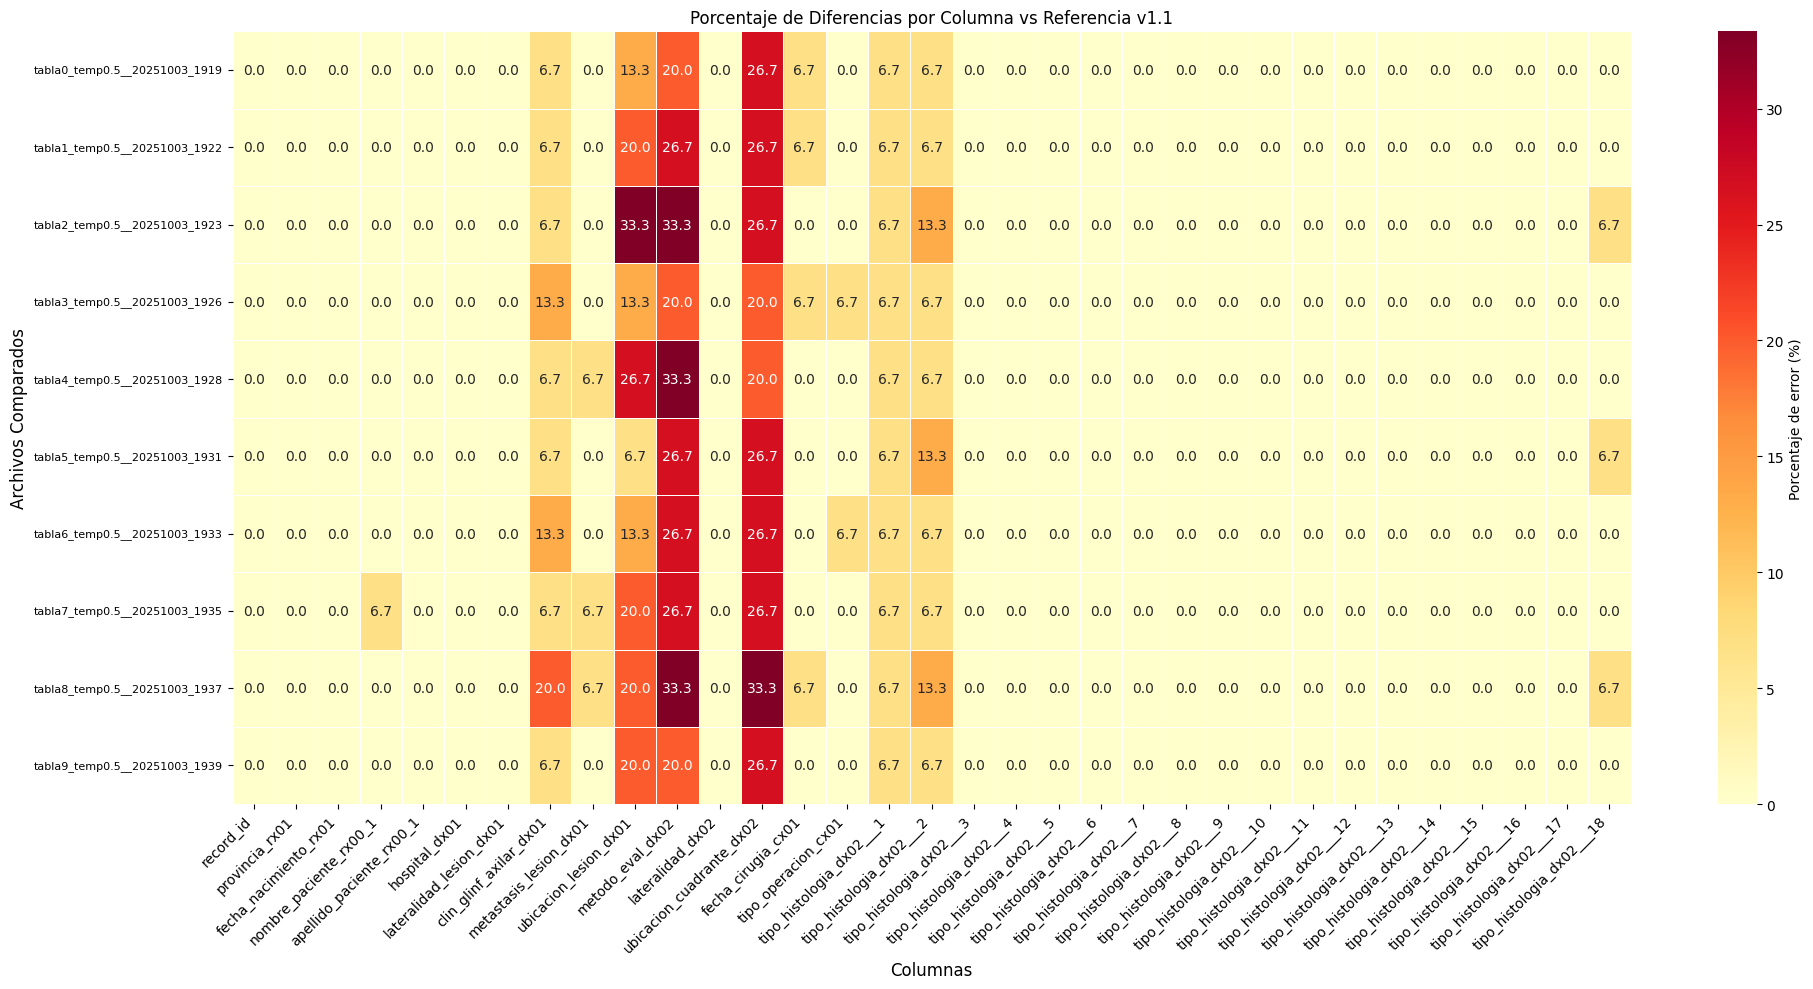

cantidad de incorrectos:
                              Total_Diferencias
tabla0_temp0.5__20251003_1919                13
tabla1_temp0.5__20251003_1922                15
tabla2_temp0.5__20251003_1923                19
tabla3_temp0.5__20251003_1926                14
tabla4_temp0.5__20251003_1928                16
tabla5_temp0.5__20251003_1931                14
tabla6_temp0.5__20251003_1933                15
tabla7_temp0.5__20251003_1935                16
tabla8_temp0.5__20251003_1937                22
tabla9_temp0.5__20251003_1939                13

Archivos con más discrepancias:
tabla8_temp0.5__20251003_1937    4.444444
tabla2_temp0.5__20251003_1923    3.838384
tabla7_temp0.5__20251003_1935    3.232323
tabla4_temp0.5__20251003_1928    3.232323
tabla6_temp0.5__20251003_1933    3.030303
tabla1_temp0.5__20251003_1922    3.030303
dtype: float64

Columnas con mas errores:
metodo_eval_dx02             26.666667
ubicacion_cuadrante_dx02     26.000000
ubicacion_lesion_dx01        18.666667
cli

In [ ]:
tabla_folder = "C:/Users/Santi/Downloads/folder-test/codigos py/temp0.5"
referencia = 'C:/Users/Santi/Downloads/folder-test/tabla-referencia-1.1.csv.xlsx'
resultados = comparar_tablas_con_referencia(referencia, tabla_folder)

print("cantidad de incorrectos:" )
print(resultados['resumen_tablas'])

print()